# A first run

The goal of this notebook is to demonstrate the modularity of OpenCDaRR, where you can build your own **things** and test it.

## Use existing kinematic and performance model
First, let's spawn our first aircraft from an existing kinematics and performance

In [1]:
from opencdarr.kinematics import FixedWing, Multirotor
from opencdarr.fleet import Agent, run_fleet
from opencdarr.performance import M600, SMALL_FIXEDWING
from opencdarr.autopilot import CruiseAutopilot
from opencdarr.scenario import create_conflict
from opencdarr.state import AircraftState

# the multirotor cruises flying north
copter = AircraftState(id="COPTER", lat=52.0, lon=4.0, trk=0.0, gs=18.0, yaw=0.0)

# spawn the plane directly in conflict
plane = create_conflict(copter, intr_id="PLANE", dpsi=90.0, dcpa=0.0,
                        tlos=30.0, rpz=50.0, gs_intr=15.0, side=1)

# We create the agent, their mission is cruising
agent_copter = Agent(copter, M600, Multirotor(), CruiseAutopilot(copter.trk, copter.gs))
agent_plane = Agent(plane, SMALL_FIXEDWING, FixedWing(), CruiseAutopilot(plane.trk, plane.gs))

# because the framework uses an agent based modelling, we should first collect the agent into one list
agents = [agent_copter, agent_plane]

[a.state.id for a in agents]

['COPTER', 'PLANE']

## Run the sim, no conflict resolution

closest approach: 0.0 m   loss of separation: True
run ended at t = 44.3 s


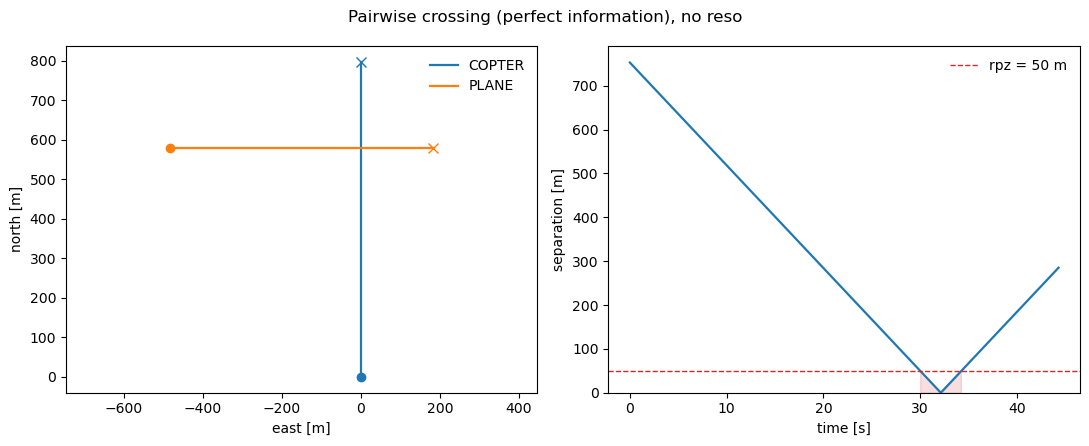

In [2]:
from opencdarr.cd import StateBased
from opencdarr.viz import plot_pairwise

run = run_fleet(
    agents, rpz=50.0, t_lookahead=20.0, dt=0.1,
    detector= StateBased(), resolver=None,
    recovery= None,
    done_timeout=10.0,
    record=True,
)
print(f"closest approach: {run.min_sep:.1f} m   loss of separation: {run.los}")
print(f"run ended at t = {run.frames[-1].t:.1f} s")

fig = plot_pairwise(run, rpz=50.0, title="Pairwise crossing (perfect information), no reso")
# fig.savefig("pairwise_clean.png", dpi=150)   # the figure handle is yours to keep

## Run the sim, with conflict resolution

closest approach: 89.3 m   loss of separation: False
run ended at t = 42.1 s


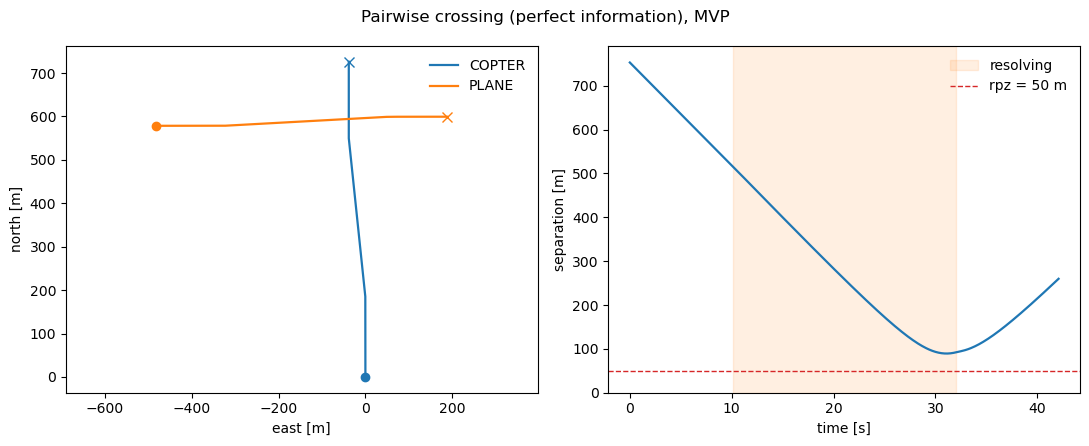

In [3]:
from opencdarr.cd import StateBased
from opencdarr.cr import MVP, VO
from opencdarr.crr import PastCPA

# we are running this sim with MVP, but you can also try with VO
run = run_fleet(
    agents, rpz=50.0, t_lookahead=20.0, dt=0.1,
    detector= StateBased(), resolver=MVP(),
    recovery= PastCPA(bouncing_guard=True),
    done_timeout=10.0,
    record=True,
)
print(f"closest approach: {run.min_sep:.1f} m   loss of separation: {run.los}")
print(f"run ended at t = {run.frames[-1].t:.1f} s")

fig = plot_pairwise(run, rpz=50.0, title="Pairwise crossing (perfect information), MVP")
# fig.savefig("pairwise_clean.png", dpi=150)   # the figure handle is yours to keep

## Run the sim, with CNS uncertainty

closest approach: 72.3 m   loss of separation: False


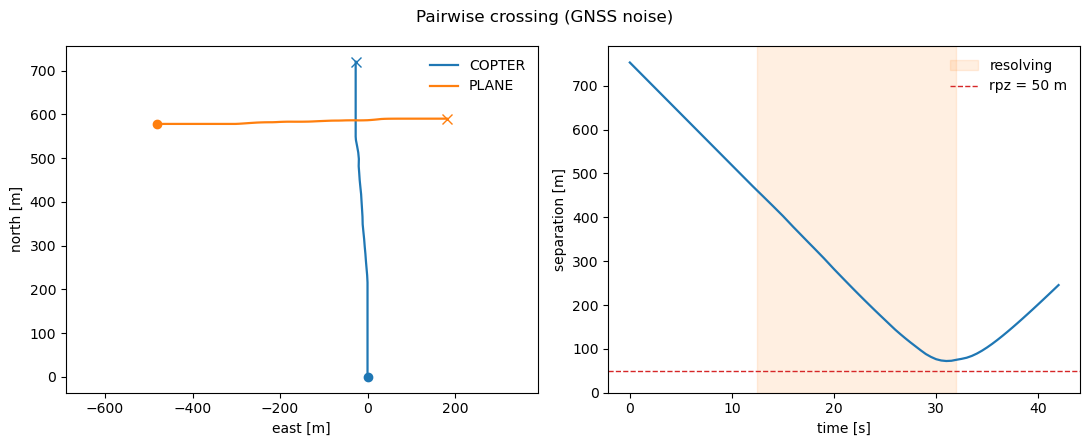

In [4]:
from dataclasses import replace
from opencdarr.cns.navigation import GnssNavigation
from opencdarr import rng

# here we asign the uncertainty into each agents
# all of them has 15 m and 1.5 m/s position and velocity uncertainty respectively
noisy_agents = [replace(a, state=replace(a.state, pos_ci95=15.0, vel_ci95=1.5)) for a in agents]

noisy_run = run_fleet(
    noisy_agents, rpz=50.0, t_lookahead=20.0, dt=0.5,
    detector=StateBased(), resolver=MVP(),
    recovery=PastCPA(bouncing_guard=True),
    navigation=GnssNavigation(), rng=rng.generator(rng.root_seed_sequence(42)),
    stop_within=100.0, done_timeout=10.0,   # stop once both reach their waypoint
    record=True,
)
print(f"closest approach: {noisy_run.min_sep:.1f} m   loss of separation: {noisy_run.los}")

fig = plot_pairwise(noisy_run, rpz=50.0, title="Pairwise crossing (GNSS noise)")

Still okay-ish, what if I add communication uncertainty?

closest approach: 109.6 m   loss of separation: False


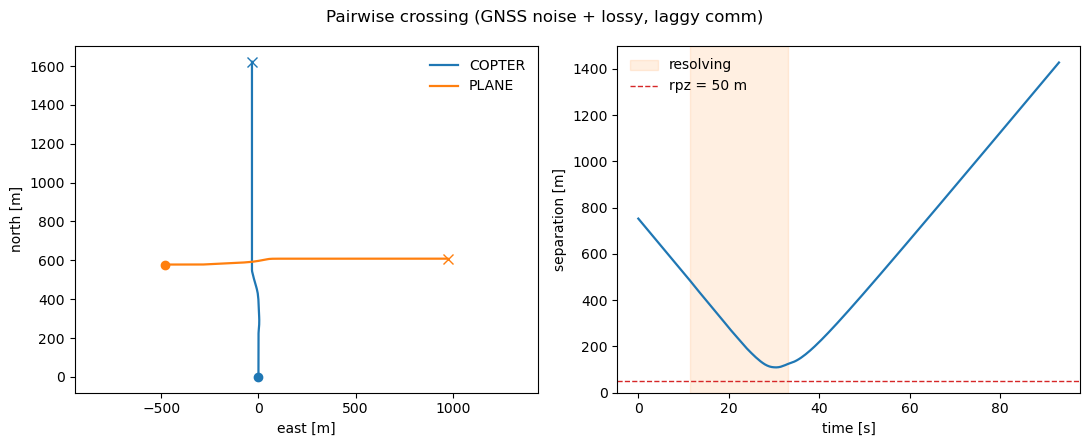

In [5]:
from opencdarr.cns import Comm, lognormal_latency

# one root seed -> two independent, reproducible streams: navigation and communication
nav_seq, comm_seq = rng.spawn(rng.root_seed_sequence(42), 2)

comm = Comm(
    reception_prob={                       # DIRECTED: keyed (source, receiver) = "from -> to"
        ("COPTER", "PLANE"): 0.9,          #   COPTER's broadcasts reach CARGO 90% of the time
        ("PLANE", "COPTER"): 0.6,          #   CARGO's reach COPTER only 60% — asymmetric link
    },                                     #   any pair you omit defaults to 1.0 (perfect)
    latency=lognormal_latency(median=0.5, sigma=0.4),   # seconds; delivered at t_meas + delay
)

noisy_run = run_fleet(
    noisy_agents, rpz=50.0, t_lookahead=20.0, dt=0.5,
    detector=StateBased(), resolver=MVP(margin=1.1),
    recovery=PastCPA(bouncing_guard=True),
    navigation=GnssNavigation(), rng=rng.generator(nav_seq),
    communication=comm,          comm_rng=rng.generator(comm_seq),   # comm needs its own stream
    stop_within=100.0, done_timeout=60.0,   # stop once both reach their waypoint
    record=True,
)
print(f"closest approach: {noisy_run.min_sep:.1f} m   loss of separation: {noisy_run.los}")

fig = plot_pairwise(noisy_run, rpz=50.0, title="Pairwise crossing (GNSS noise + lossy, laggy comm)")

## Run a MC Simulation
Whoaa, that was actually pretty good. But the CPA distance is smaller now. Maybe we need to run more simulation! Using previously defined comm and nav...

In [6]:
n_runs = 200
outcomes = [
    run_fleet(
        noisy_agents, rpz=50.0, t_lookahead=20.0, dt=0.2,
        detector=StateBased(), resolver=MVP(),
        recovery=PastCPA(bouncing_guard=True),
        navigation=GnssNavigation(), rng=rng.generator(nav_seq),
        communication=comm,          comm_rng=rng.generator(comm_seq),   # per-run comm stream now
        stop_within=100.0, done_timeout=60.0,   # each run flies to the waypoint
        record=True,
    )
    for nav_seq, comm_seq in (rng.spawn(sub, 2) for sub in rng.spawn(rng.root_seed_sequence(42), n_runs))
]

lost = sum(o.los for o in outcomes)
min_seps = [o.min_sep for o in outcomes]
print(f"loss of separation in {lost}/{n_runs} runs  (rate ~ {lost / n_runs:.3f})")
print(f"closest approach over the sweep: min {min(min_seps):.1f} m, median {sorted(min_seps)[n_runs // 2]:.1f} m")

loss of separation in 2/200 runs  (rate ~ 0.010)
closest approach over the sweep: min 48.1 m, median 96.3 m


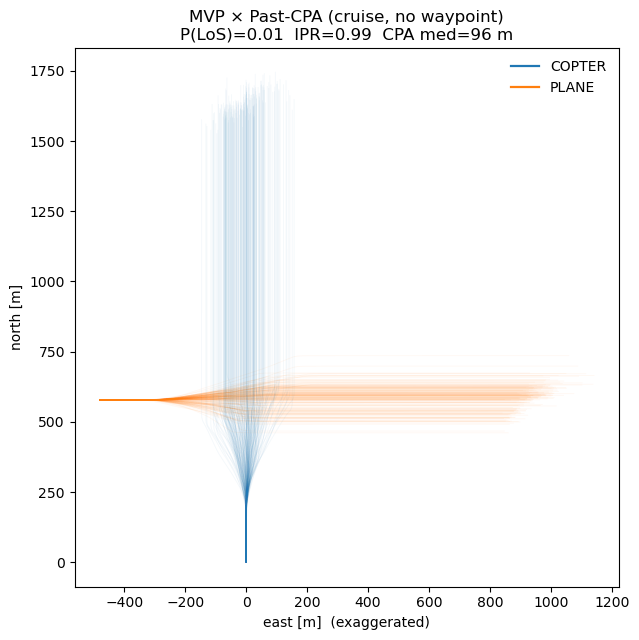

In [7]:
from opencdarr.viz import plot_pairwise_montecarlo


## if you encounter error here, most likely you haven't uncomment record=True above
fig = plot_pairwise_montecarlo(outcomes, title="MVP × Past-CPA (cruise, no waypoint)")

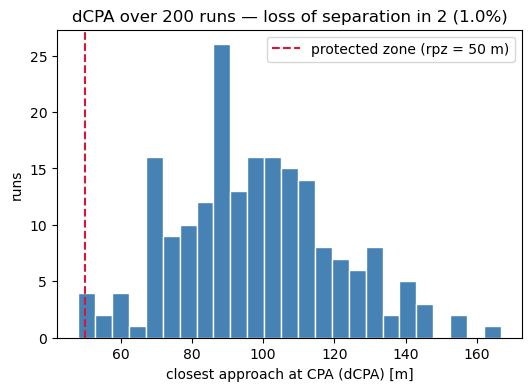

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(min_seps, bins=25, color="steelblue", edgecolor="white")
ax.axvline(50.0, color="crimson", linestyle="--", label="protected zone (rpz = 50 m)")
ax.set_xlabel("closest approach at CPA (dCPA) [m]")
ax.set_ylabel("runs")
ax.set_title(f"dCPA over {len(min_seps)} runs — loss of separation in {lost} ({lost/len(min_seps):.1%})")
ax.legend()
plt.show()

## Run a MC Simulation, but with waypoint

In [9]:
from opencdarr.autopilot import WaypointAutopilot
from opencdarr.mission import Mission
from opencdarr import geo

# from the previous mission assignment of an agent, we can write the copter agent a waypoint for its mission
wp_copter = geo.forward(copter.lat, copter.lon, copter.trk, copter.gs * 75.0)
agent_copter = Agent(copter, M600,  Multirotor(),     WaypointAutopilot(Mission(goto=wp_copter)))

# update the agent now
agents = [agent_copter, agent_plane]
noisy_agents = [replace(a, state=replace(a.state, pos_ci95=15.0, vel_ci95=1.5)) for a in agents]

# and let it go... let it go...
n_runs = 200
outcomes = [
    run_fleet(
        noisy_agents, rpz=50.0, t_lookahead=20.0, dt=0.2,
        detector=StateBased(), resolver=MVP(),
        recovery=PastCPA(bouncing_guard=True),
        navigation=GnssNavigation(), rng=rng.generator(nav_seq),
        communication=comm,          comm_rng=rng.generator(comm_seq),   # per-run comm stream now
        stop_within=50.0, done_timeout=60.0,   # each run flies to the waypoint
        record=True,
    )
    for nav_seq, comm_seq in (rng.spawn(sub, 2) for sub in rng.spawn(rng.root_seed_sequence(42), n_runs))
]

lost = sum(o.los for o in outcomes)
min_seps = [o.min_sep for o in outcomes]
print(f"loss of separation in {lost}/{n_runs} runs  (rate ~ {lost / n_runs:.3f})")
print(f"closest approach over the sweep: min {min(min_seps):.1f} m, median {sorted(min_seps)[n_runs // 2]:.1f} m")

loss of separation in 2/200 runs  (rate ~ 0.010)
closest approach over the sweep: min 48.1 m, median 96.3 m


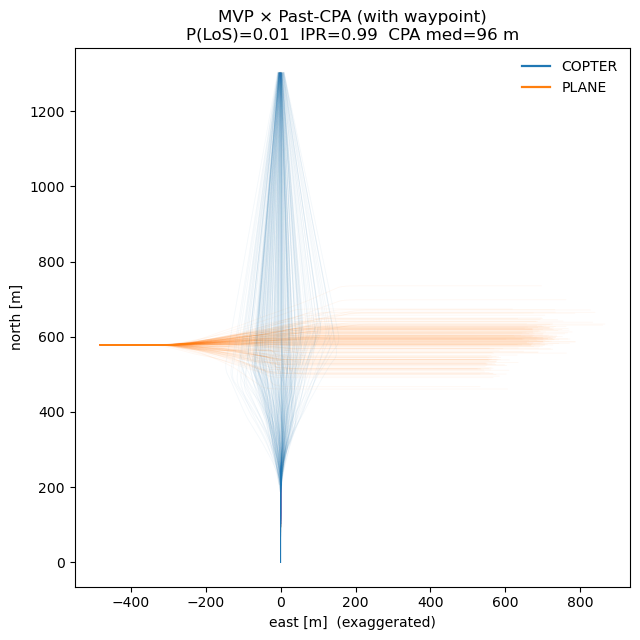

In [10]:
from opencdarr.viz import plot_pairwise_montecarlo

## if you encounter error here, most likely you haven't uncomment record=True above
fig = plot_pairwise_montecarlo(outcomes, title="MVP × Past-CPA (with waypoint)")

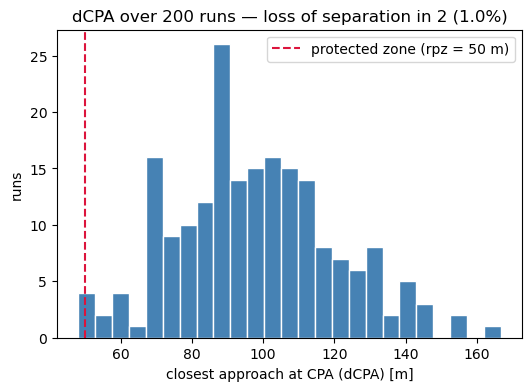

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(min_seps, bins=25, color="steelblue", edgecolor="white")
ax.axvline(50.0, color="crimson", linestyle="--", label="protected zone (rpz = 50 m)")
ax.set_xlabel("closest approach at CPA (dCPA) [m]")
ax.set_ylabel("runs")
ax.set_title(f"dCPA over {len(min_seps)} runs — loss of separation in {lost} ({lost/len(min_seps):.1%})")
ax.legend()
plt.show()

## Finally, with wind

In [12]:
import numpy as np

WINDCOL = "#f2a6a6"

def wind_field(ax, wind, xlim, ylim, n=7):
    """Faint background velocity-vector field (arrows point downwind)."""
    xx, yy = np.meshgrid(np.linspace(*xlim, n), np.linspace(*ylim, n))
    if wind.speed < 1e-9:
        ax.scatter(xx, yy, s=3, color="0.8", zorder=0)
        return
    we, wn = wind.components()
    length = (xlim[1] - xlim[0]) / (n - 1) * 0.6
    u = np.full_like(xx, we / wind.speed * length)
    v = np.full_like(yy, wn / wind.speed * length)
    ax.quiver(xx, yy, u, v, color=WINDCOL, alpha=0.2, scale=1.0, scale_units="xy",
              angles="xy", width=0.007, zorder=0)

In [13]:
from opencdarr.autopilot import WaypointAutopilot
from opencdarr.mission import Mission
from opencdarr.wind import NO_WIND, WindField

wind = WindField.from_met(coming_from_deg=30.0, speed=10.0)

# and let it go... let it go...
n_runs = 100
outcomes = [
    run_fleet(
        noisy_agents, rpz=50.0, t_lookahead=20.0, dt=0.2,
        wind = wind,
        detector=StateBased(), resolver=MVP(),
        recovery=PastCPA(bouncing_guard=True),
        navigation=GnssNavigation(), rng=rng.generator(nav_seq),
        communication=comm,          comm_rng=rng.generator(comm_seq),   # per-run comm stream now
        stop_within=100.0, done_timeout=60.0,   # each run flies to the waypoint
        record=True,
    )
    for nav_seq, comm_seq in (rng.spawn(sub, 2) for sub in rng.spawn(rng.root_seed_sequence(42), n_runs))
]

lost = sum(o.los for o in outcomes)
min_seps = [o.min_sep for o in outcomes]
print(f"loss of separation in {lost}/{n_runs} runs  (rate ~ {lost / n_runs:.3f})")
print(f"closest approach over the sweep: min {min(min_seps):.1f} m, median {sorted(min_seps)[n_runs // 2]:.1f} m")

loss of separation in 5/100 runs  (rate ~ 0.050)
closest approach over the sweep: min 45.6 m, median 73.7 m


(-57.48179323391709, 1207.117657912259)

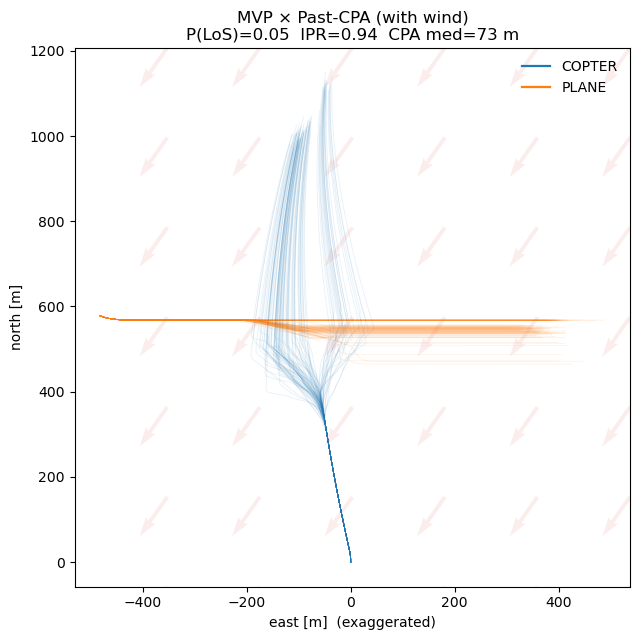

In [14]:
import matplotlib.pyplot as plt

fig = plot_pairwise_montecarlo(outcomes, title="MVP × Past-CPA (with wind)")
ax = fig.axes[0]
xlim, ylim = ax.get_xlim(), ax.get_ylim()

wind_field(ax, wind, xlim, ylim)

ax.set_xlim(*xlim)   # quiver's own autoscale can nudge the limits — pin them back
ax.set_ylim(*ylim)

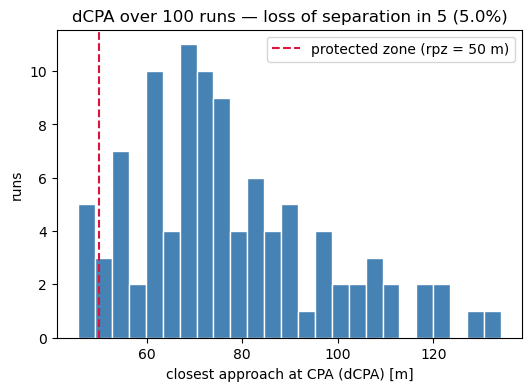

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(min_seps, bins=25, color="steelblue", edgecolor="white")
ax.axvline(50.0, color="crimson", linestyle="--", label="protected zone (rpz = 50 m)")
ax.set_xlabel("closest approach at CPA (dCPA) [m]")
ax.set_ylabel("runs")
ax.set_title(f"dCPA over {len(min_seps)} runs — loss of separation in {lost} ({lost/len(min_seps):.1%})")
ax.legend()
plt.show()